In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [2]:
df = pd.read_csv('Medicaldataset.csv')
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [3]:
df.shape

(1319, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [7]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

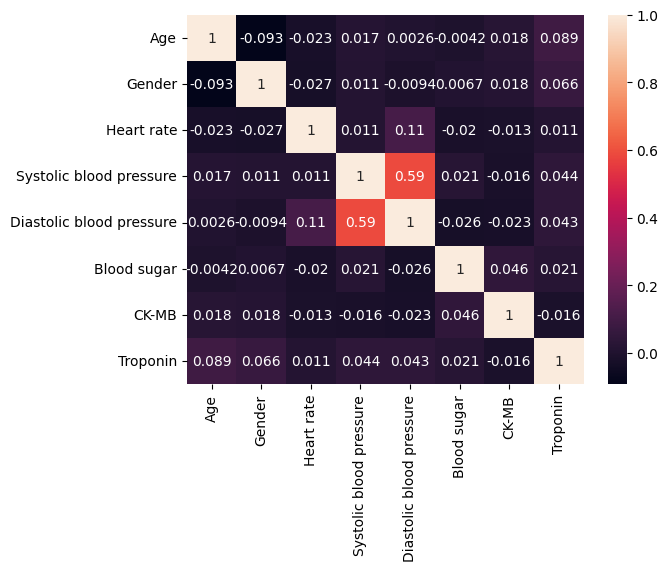

In [8]:
sns.heatmap(x.corr(),annot=True)
plt.show()

In [9]:
y.value_counts()

Result
positive    810
negative    509
Name: count, dtype: int64

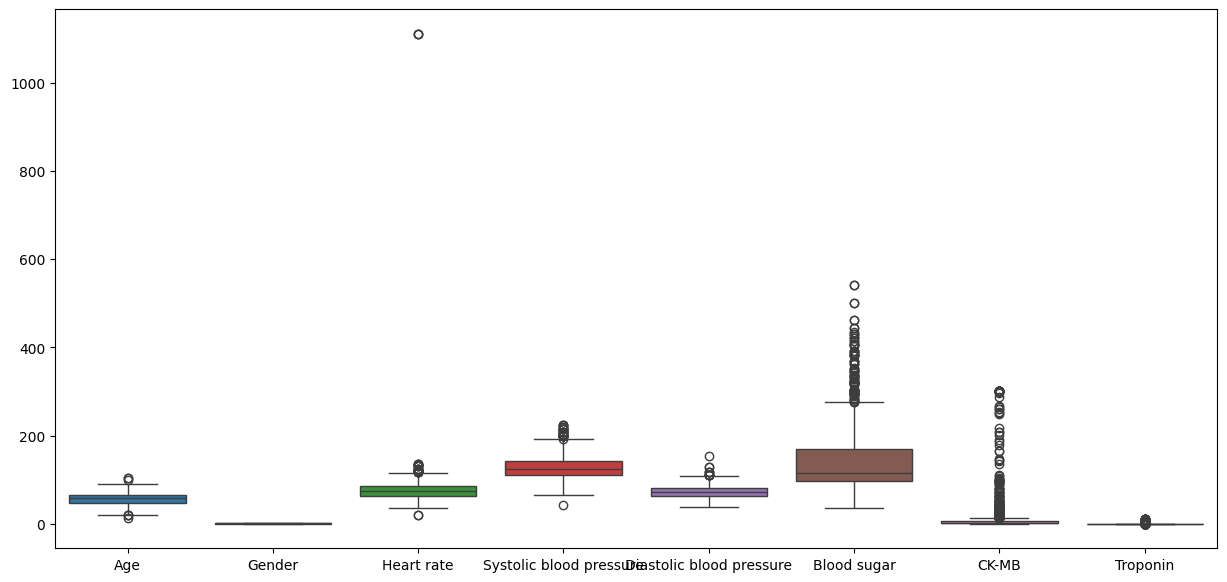

In [10]:
plt.figure(figsize=(15,7))
sns.boxplot(data=x)
plt.show()

In [11]:
from imblearn.over_sampling import SMOTE
re_sampling = SMOTE()

X_resampled, y_resampled = re_sampling.fit_resample(x, y)
y_resampled.value_counts()

Result
negative    810
positive    810
Name: count, dtype: int64

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [28]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

le = LabelEncoder()
ss = StandardScaler()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [29]:
from sklearn.linear_model import LogisticRegression
models = {
    "LogisticRegression":LogisticRegression(),
    "SVC":SVC(),
    "RandomForestClassifier":RandomForestClassifier(),
    "GradientBoostingClassifier":GradientBoostingClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier()
}

In [30]:
def model_evaluate(y_true,y_pred):
    acc = accuracy_score(y_true,y_pred)
    cr = classification_report(y_true,y_pred)
    cm = confusion_matrix(y_true,y_pred)
    
    print(f"Accuracy Score: {acc}")
    print(f"Classification Report: {cr}")
    sns.heatmap(cm,annot=True)
    plt.show()

In [31]:
def model_train(X,Y):
    for name,model in models.items():
        model.fit(X,Y)
        y_pred = model.predict(X_test)
    
    print("Model Training Success")
    
    print(f"Model Name : {name}")
    
    model_evaluate(y_test,y_pred)
    print("="*100)
        

Model Training Success
Model Name : AdaBoostClassifier
Accuracy Score: 0.9845679012345679
Classification Report:               precision    recall  f1-score   support

           0       0.99      0.98      0.99       168
           1       0.98      0.99      0.98       156

    accuracy                           0.98       324
   macro avg       0.98      0.98      0.98       324
weighted avg       0.98      0.98      0.98       324



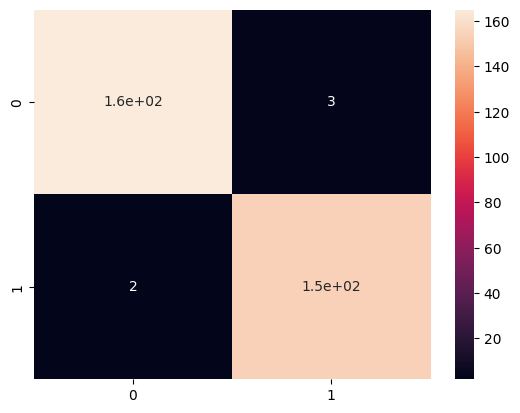

In [32]:
model_train(X_train,y_train)

Accuracy Score: 0.9876543209876543
Classification Report:               precision    recall  f1-score   support

           0       0.99      0.99      0.99       168
           1       0.99      0.99      0.99       156

    accuracy                           0.99       324
   macro avg       0.99      0.99      0.99       324
weighted avg       0.99      0.99      0.99       324



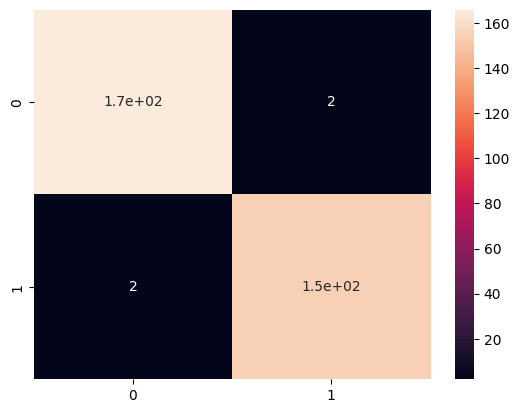

In [33]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

model_evaluate(y_test,y_pred)

In [34]:
import pickle
pickle.dump(rf,open("model.pkl",'wb'))